# **Import**

In [ ]:
# =============================================================================
# 1. IMPORT LIBRARY
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')   # non-interactive backend agar bisa berjalan tanpa display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import json
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SKPipeline

import xgboost as xgb

!pip install skl2onnx
!pip install onnxruntime

from skl2onnx import convert_sklearn, update_registered_converter
from skl2onnx.common.data_types import FloatTensorType
import onnxruntime as rt

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Style visual
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor'  : '#f9f9f9',
    'axes.grid'       : True,
    'grid.alpha'      : 0.4,
    'font.size'       : 11,
})
PALETTE = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc948', '#b07aa1']

print("=" * 65)
print("  PIPELINE ML - DETEKSI RISIKO OBESITAS")
print("=" * 65)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 18.6 MB/s eta 0:00:00
  PIPELINE ML - DETEKSI RISIKO OBESITAS


# **Load**

In [ ]:
# =============================================================================
# 2. LOAD DATASET
# =============================================================================
print("\n[2] LOAD DATASET")
print("-" * 45)

URL = "https://raw.githubusercontent.com/Putraaa27/diabetes/refs/heads/main/ObesityDataSet_raw_and_data_sinthetic.csv"
df_raw = pd.read_csv(URL)

print(f"Shape dataset  : {df_raw.shape}")
print(f"\nKolom & tipe data:")
print(df_raw.dtypes)
print(f"\n5 baris pertama:")
print(df_raw.head())

print(f"\nDistribusi Target (NObeyesdad):")
print(df_raw['NObeyesdad'].value_counts())


[2] LOAD DATASET
---------------------------------------------
Shape dataset  : (2111, 17)

Kolom & tipe data:
Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

5 baris pertama:
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   

# **Cleaning**

In [ ]:
# =============================================================================
# 3. DATA CLEANING
# =============================================================================
print("\n[3] DATA CLEANING")
print("-" * 45)

df = df_raw.copy()
TARGET_COL = 'NObeyesdad'

# --- 3a. Missing values ---
print("Cek missing values per kolom:")
mv = df.isnull().sum()
print(mv[mv > 0] if mv.sum() > 0 else "  Tidak ada missing values ✓")

# --- 3b. Duplikat ---
n_dup = df.duplicated().sum()
print(f"\nJumlah data duplikat: {n_dup}")
if n_dup > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"  Duplikat dihapus. Shape baru: {df.shape}")

# --- 3c. Identifikasi kolom berdasarkan tipe ---
# Kolom kategorikal biner (yes/no)
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']

# Kolom kategorikal ordinal (Sometimes, Frequently, Always, no)
ordinal_cols_map = {
    'CAEC': ['no', 'Sometimes', 'Frequently', 'Always'],
    'CALC': ['no', 'Sometimes', 'Frequently', 'Always'],
}

# Kolom nominal multi-kategori
nominal_cols = ['Gender', 'MTRANS']

# Kolom numerik (sudah numerik, tidak perlu encode)
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

print(f"\nKolom binary    : {binary_cols}")
print(f"Kolom ordinal   : {list(ordinal_cols_map.keys())}")
print(f"Kolom nominal   : {nominal_cols}")
print(f"Kolom numerik   : {numeric_cols}")
print(f"Kolom target    : {TARGET_COL}")

# --- 3d. Encoding ---
df_encoded = df.copy()

# Binary: yes=1, no=0
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({'yes': 1, 'no': 0})
    print(f"  Binary encode '{col}': yes→1, no→0")

# Ordinal: urutan sesuai tingkat frekuensi
for col, order in ordinal_cols_map.items():
    mapping = {val: i for i, val in enumerate(order)}
    df_encoded[col] = df_encoded[col].map(mapping)
    print(f"  Ordinal encode '{col}': {mapping}")



# Nominal: Label Encoding (LR & RF tidak sensitif urutan, XGB juga)
le_gender = LabelEncoder()
df_encoded['Gender'] = le_gender.fit_transform(df_encoded['Gender'])
print(f"  Label encode 'Gender': {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")

le_mtrans = LabelEncoder()
df_encoded['MTRANS'] = le_mtrans.fit_transform(df_encoded['MTRANS'])
print(f"  Label encode 'MTRANS': {dict(zip(le_mtrans.classes_, le_mtrans.transform(le_mtrans.classes_)))}")

# Encode target
le_target = LabelEncoder()
df_encoded[TARGET_COL] = le_target.fit_transform(df_encoded[TARGET_COL])
CLASS_NAMES = le_target.classes_.tolist()
N_CLASSES   = len(CLASS_NAMES)
print(f"\nTarget encode '{TARGET_COL}':")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i} → {name}")

# Pastikan semua kolom numerik
print(f"\nCek tipe data setelah encoding:")
print(df_encoded.dtypes)
print(f"\nMissing values setelah encoding: {df_encoded.isnull().sum().sum()}")

# Imputasi sisa missing (jika ada) dengan median
if df_encoded.isnull().sum().sum() > 0:
    imp = SimpleImputer(strategy='median')
    df_encoded = pd.DataFrame(imp.fit_transform(df_encoded), columns=df_encoded.columns)
    print("  Imputasi median diterapkan.")

print(f"\nDataset final setelah cleaning: {df_encoded.shape}")


[3] DATA CLEANING
---------------------------------------------
Cek missing values per kolom:
  Tidak ada missing values ✓

Jumlah data duplikat: 24
  Duplikat dihapus. Shape baru: (2087, 17)

Kolom binary    : ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
Kolom ordinal   : ['CAEC', 'CALC']
Kolom nominal   : ['Gender', 'MTRANS']
Kolom numerik   : ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Kolom target    : NObeyesdad
  Binary encode 'family_history_with_overweight': yes→1, no→0
  Binary encode 'FAVC': yes→1, no→0
  Binary encode 'SMOKE': yes→1, no→0
  Binary encode 'SCC': yes→1, no→0
  Ordinal encode 'CAEC': {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
  Ordinal encode 'CALC': {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
  Label encode 'Gender': {'Female': np.int64(0), 'Male': np.int64(1)}
  Label encode 'MTRANS': {'Automobile': np.int64(0), 'Bike': np.int64(1), 'Motorbike': np.int64(2), 'Public_Transportation': np.int64(3), 'Wa

# **EDA**


[4] EXPLORATORY DATA ANALYSIS
---------------------------------------------
Statistik deskriptif:
         Gender       Age    Height    Weight  family_history_with_overweight      FAVC      FCVC       NCP      CAEC     SMOKE      CH2O       SCC       FAF       TUE      CALC    MTRANS  NObeyesdad
count  2087.000  2087.000  2087.000  2087.000                        2087.000  2087.000  2087.000  2087.000  2087.000  2087.000  2087.000  2087.000  2087.000  2087.000  2087.000  2087.000    2087.000
mean      0.504    24.353     1.703    86.859                           0.825     0.884     2.421     2.701     1.146     0.021     2.005     0.046     1.013     0.663     0.730     2.359       3.014
std       0.500     6.369     0.093    26.191                           0.380     0.321     0.535     0.765     0.459     0.144     0.608     0.210     0.853     0.608     0.517     1.265       1.948
min       0.000    14.000     1.450    39.000                           0.000     0.000     1.000    

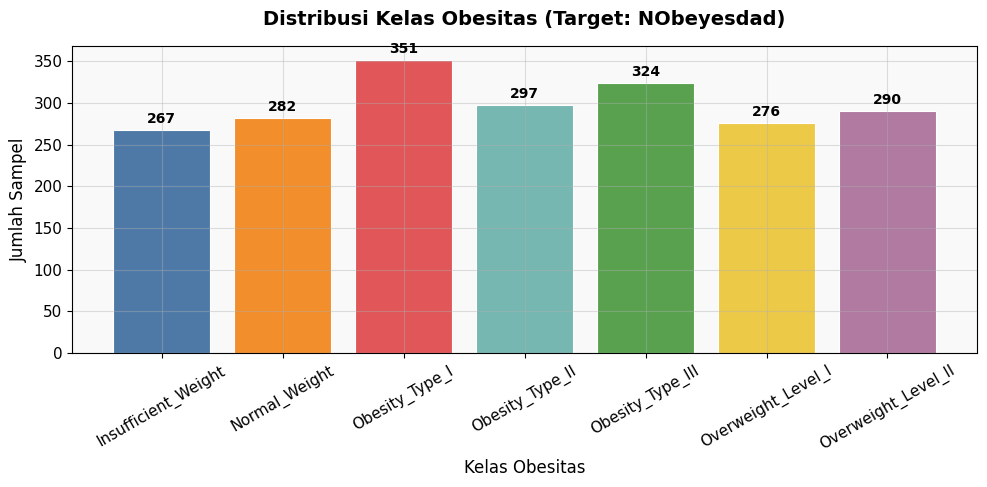

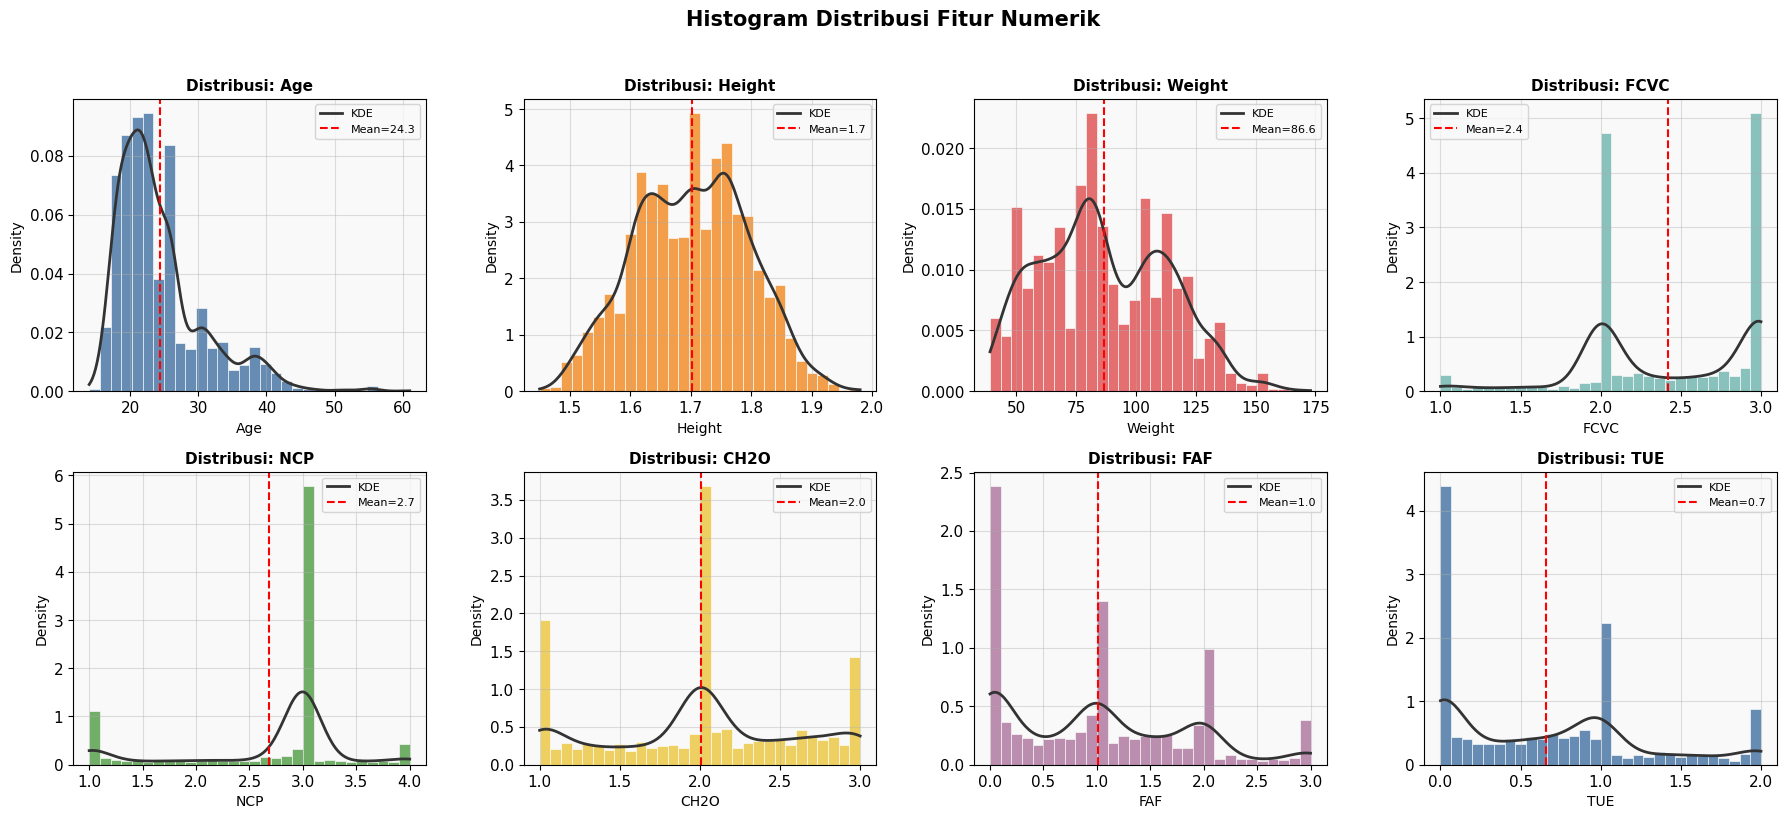

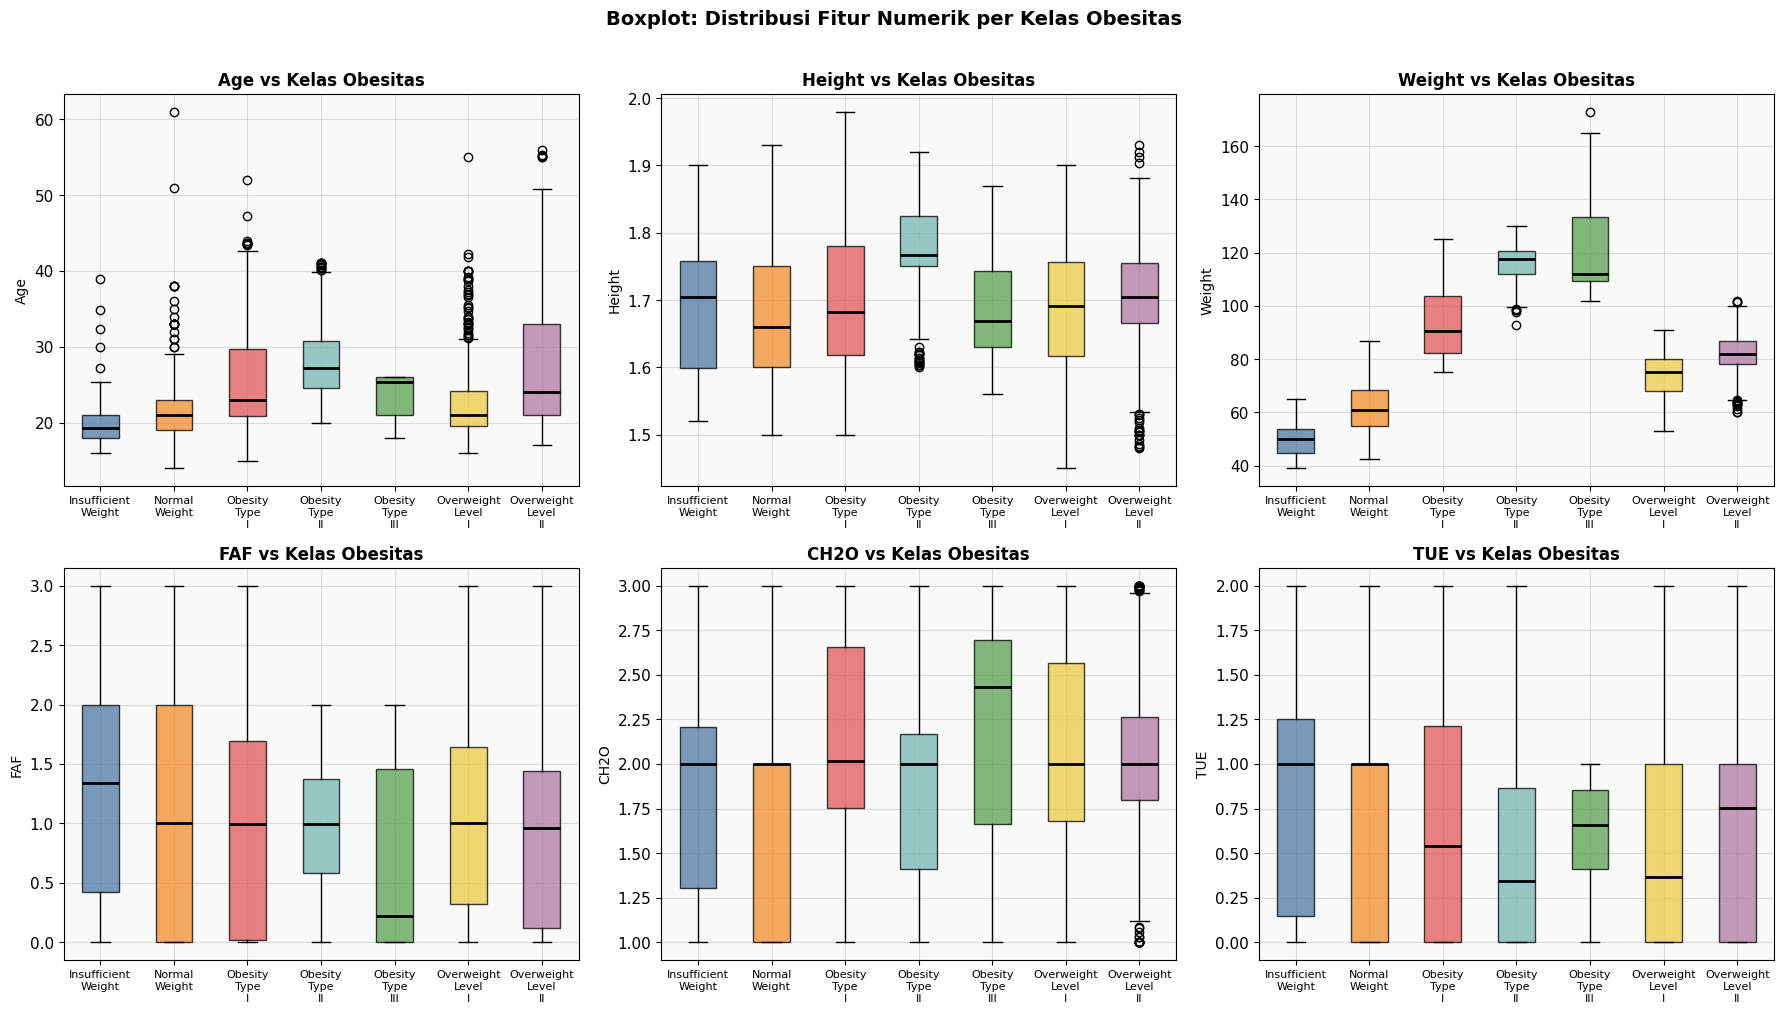

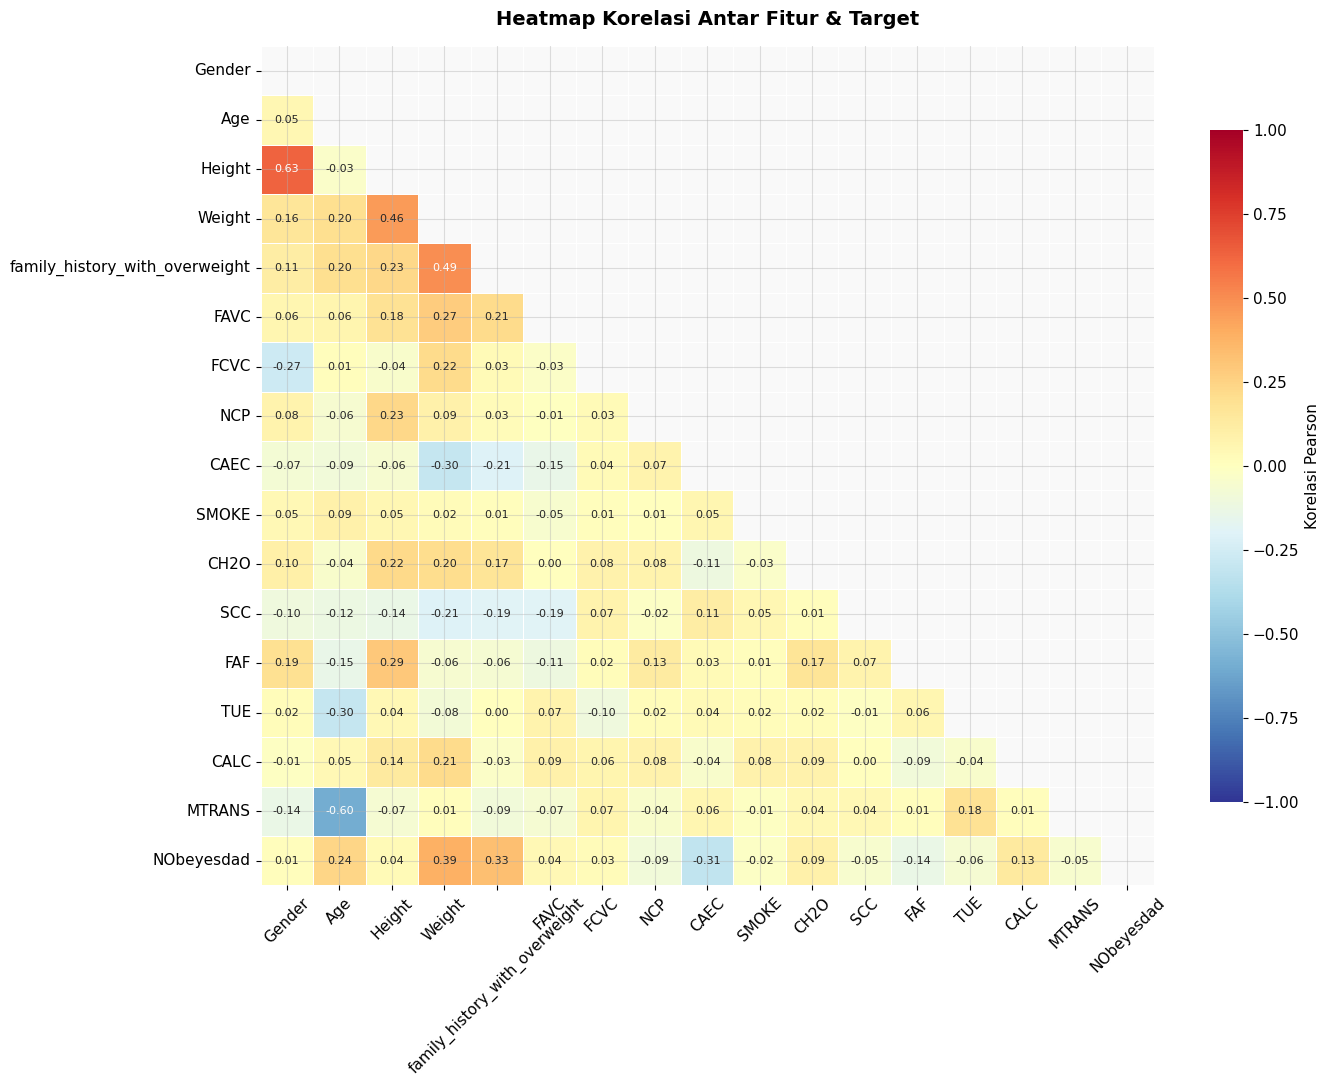


[Insight EDA]
  - Dataset: 2087 sampel, 16 fitur, 7 kelas target
  - Kelas terbanyak : 'Obesity_Type_I' (351 sampel)
  - Kelas tersedikit: 'Insufficient_Weight' (272 sampel)
  - Fitur paling berkorelasi dengan target: 'Weight' (0.389)
  - Weight & Height adalah prediktor utama obesitas (sesuai BMI)


In [ ]:
# =============================================================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================
print("\n[4] EXPLORATORY DATA ANALYSIS")
print("-" * 45)

# Gunakan backend interaktif untuk menampilkan grafik
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline') # Standar untuk Colab/Jupyter

print("Statistik deskriptif:")
print(df_encoded.describe().round(3).to_string())

print(f"\nDistribusi target '{TARGET_COL}':")
target_dist = df_encoded[TARGET_COL].value_counts().sort_index()
for idx, cnt in target_dist.items():
    print(f"  {CLASS_NAMES[int(idx)]:35s} ({int(idx)}): {cnt:4d} ({cnt/len(df_encoded)*100:.1f}%)")

# ============================================================
# PLOT 1: Distribusi Target (Bar Chart)
# ============================================================
plt.figure(figsize=(10, 5))
bars = plt.bar(
    [CLASS_NAMES[int(i)] for i in target_dist.index],
    target_dist.values,
    color=PALETTE[:N_CLASSES],
    edgecolor='white', linewidth=0.8
)
plt.title('Distribusi Kelas Obesitas (Target: NObeyesdad)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kelas Obesitas', fontsize=12)
plt.ylabel('Jumlah Sampel', fontsize=12)
plt.xticks(rotation=30)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 5,
             str(int(h)), ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show() # Tampilkan grafik

# ============================================================
# PLOT 2: Histogram Distribusi Fitur Numerik
# ============================================================
num_plot_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_plot_cols):
    ax = axes[i]
    data_col = df_raw[col].dropna().astype(float)
    n_bins = min(30, int(np.sqrt(len(data_col))))
    ax.hist(data_col, bins=n_bins, color=PALETTE[i % len(PALETTE)],
            edgecolor='white', linewidth=0.5, alpha=0.85, density=True)

    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(data_col)
        x_range = np.linspace(data_col.min(), data_col.max(), 200)
        ax.plot(x_range, kde(x_range), color='#333333', linewidth=2, label='KDE')
    except Exception:
        pass

    ax.set_title(f'Distribusi: {col}', fontsize=11, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    mean_val = data_col.mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean={mean_val:.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Histogram Distribusi Fitur Numerik', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 3: Boxplot — Fitur Numerik vs Kelas Obesitas
# ============================================================
boxplot_features = ['Age', 'Height', 'Weight', 'FAF', 'CH2O', 'TUE']
df_box = df_raw[boxplot_features + [TARGET_COL]].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(boxplot_features):
    ax = axes[i]
    groups = [df_box[df_box[TARGET_COL] == cls][col].dropna().values for cls in CLASS_NAMES]
    bp = ax.boxplot(groups, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(f'{col} vs Kelas Obesitas', fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, len(CLASS_NAMES) + 1))
    ax.set_xticklabels([n.replace('_', '\n') for n in CLASS_NAMES], fontsize=8, rotation=0)
    ax.set_ylabel(col, fontsize=10)

plt.suptitle('Boxplot: Distribusi Fitur Numerik per Kelas Obesitas', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 4: Heatmap Korelasi
# ============================================================
plt.figure(figsize=(14, 11))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    cmap='RdYlBu_r',
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    linecolor='white',
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8, 'label': 'Korelasi Pearson'},
    vmin=-1, vmax=1
)
plt.title('Heatmap Korelasi Antar Fitur & Target', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Insight EDA
print("\n[Insight EDA]")
print(f"  - Dataset: {df_encoded.shape[0]} sampel, {df_encoded.shape[1]-1} fitur, {N_CLASSES} kelas target")
target_dist_raw = df_raw[TARGET_COL].value_counts()
print(f"  - Kelas terbanyak : '{target_dist_raw.idxmax()}' ({target_dist_raw.max()} sampel)")
print(f"  - Kelas tersedikit: '{target_dist_raw.idxmin()}' ({target_dist_raw.min()} sampel)")
corr_with_target = df_encoded.drop(columns=[TARGET_COL]).corrwith(df_encoded[TARGET_COL]).abs()
top_feat = corr_with_target.idxmax()
print(f"  - Fitur paling berkorelasi dengan target: '{top_feat}' ({corr_with_target[top_feat]:.3f})")
print(f"  - Weight & Height adalah prediktor utama obesitas (sesuai BMI)")

# **FE**

In [ ]:
# =============================================================================
# 5. FEATURE ENGINEERING
# =============================================================================
print("\n[5] FEATURE ENGINEERING")
print("-" * 45)

X = df_encoded.drop(columns=[TARGET_COL])
y = df_encoded[TARGET_COL].astype(int)

FEATURE_NAMES = X.columns.tolist()
N_FEATURES    = len(FEATURE_NAMES)

print(f"Fitur (X) : {N_FEATURES} kolom")
print(f"Target (y): {N_CLASSES} kelas")
print(f"Kolom X   : {FEATURE_NAMES}")

# Split 80:20 dengan stratify agar distribusi kelas terjaga
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

# Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Simpan scaler untuk digunakan kembali jika diperlukan secara manual
with open('scaler_obesity.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("StandardScaler diterapkan & disimpan ke 'scaler_obesity.pkl' ✓")

# Cek apakah scaling berhasil (Mean mendekati 0, Std mendekati 1)
print(f"Rata-rata fitur setelah scaling: {X_train_scaled.mean():.2f}")
print(f"Standar deviasi fitur setelah scaling: {X_train_scaled.std():.2f}")


[5] FEATURE ENGINEERING
---------------------------------------------
Fitur (X) : 16 kolom
Target (y): 7 kelas
Kolom X   : ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS']

Train: (1669, 16), Test: (418, 16)
StandardScaler diterapkan & disimpan ke 'scaler_obesity.pkl' ✓
Rata-rata fitur setelah scaling: 0.00
Standar deviasi fitur setelah scaling: 1.00


# **Model dan Train**

In [ ]:
# =============================================================================
# 6-7. MODELING & TRAINING
# =============================================================================
print("\n[6-7] MODELING & TRAINING")
print("-" * 45)

# --- Model 1: Logistic Regression ---
print("Training Logistic Regression...", end='', flush=True)
lr_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
    C=1.0,
    solver='lbfgs',
    multi_class='multinomial',
    n_jobs=-1
)
lr_model.fit(X_train_scaled, y_train)
print(" SELESAI ✓")

# --- Model 2: Random Forest ---
print("Training Random Forest...      ", end='', flush=True)
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
print(" SELESAI ✓")

# --- Model 3: XGBoost ---
print("Training XGBoost...            ", end='', flush=True)
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    verbosity=0,
    use_label_encoder=False
)
xgb_model.fit(X_train_scaled, y_train)
print(" SELESAI ✓")


[6-7] MODELING & TRAINING
---------------------------------------------
Training Logistic Regression... SELESAI ✓
Training Random Forest...       SELESAI ✓
Training XGBoost...             SELESAI ✓


# **Evaluasi**


[8] EVALUASI MODEL
---------------------------------------------

[Logistic Regression]
  Accuracy  : 0.8900
  F1-Score  : 0.8874

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.85      0.98      0.91        53
      Normal_Weight       0.91      0.70      0.79        57
     Obesity_Type_I       0.92      0.94      0.93        70
    Obesity_Type_II       0.94      1.00      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.79      0.87      0.83        55
Overweight_Level_II       0.81      0.72      0.76        58

           accuracy                           0.89       418
          macro avg       0.89      0.89      0.88       418
       weighted avg       0.89      0.89      0.89       418


[Random Forest]
  Accuracy  : 0.9498
  F1-Score  : 0.9506

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       

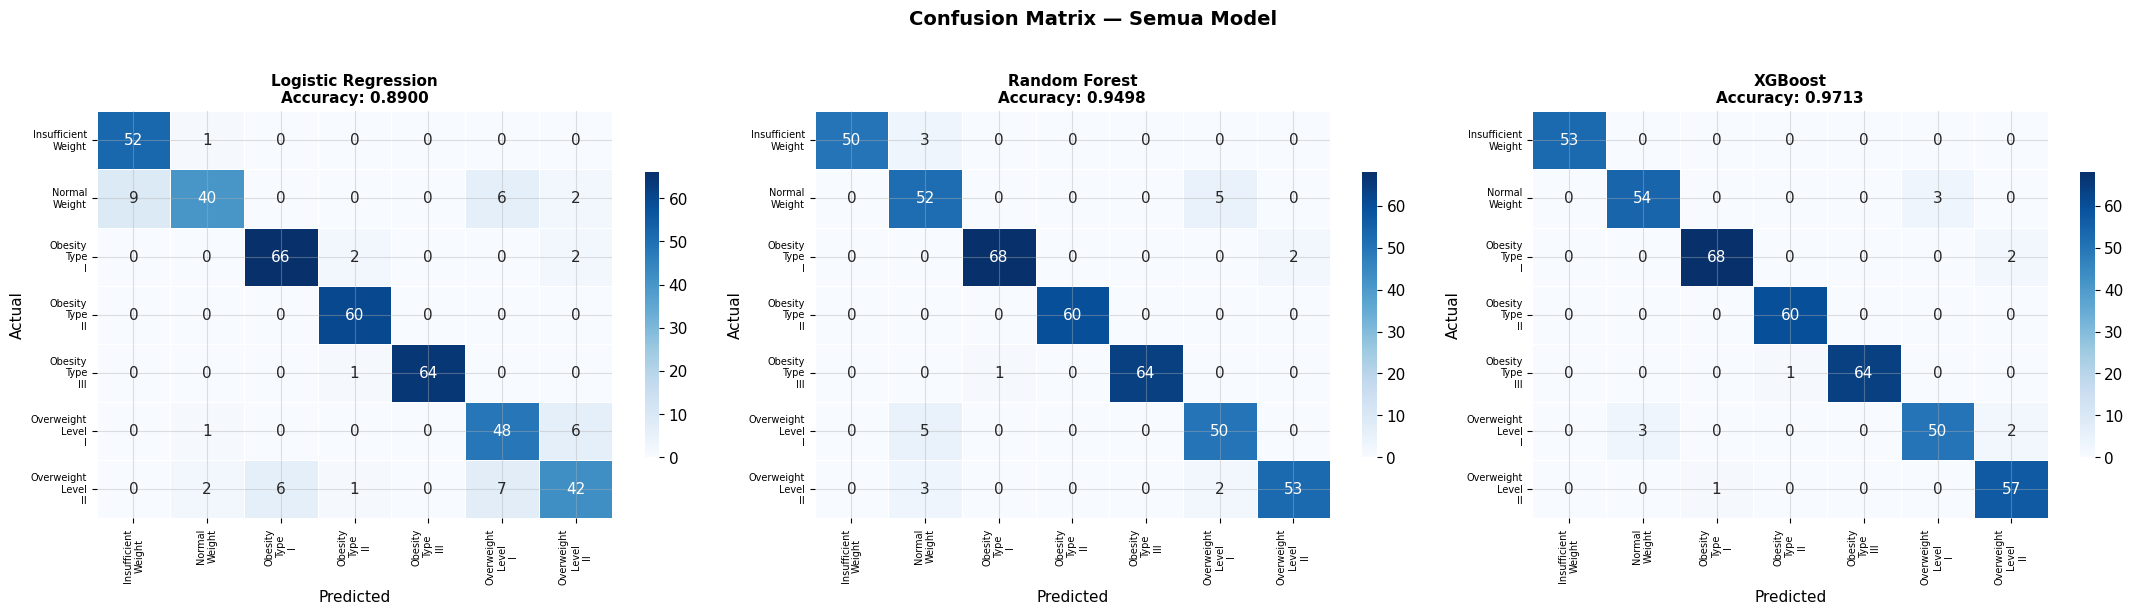

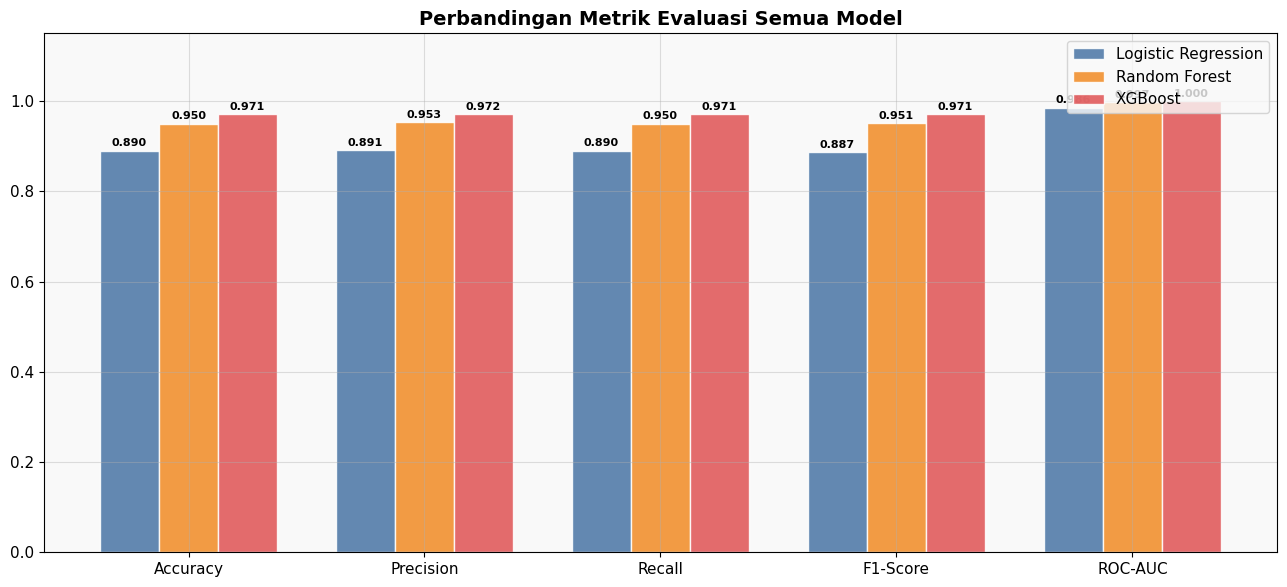

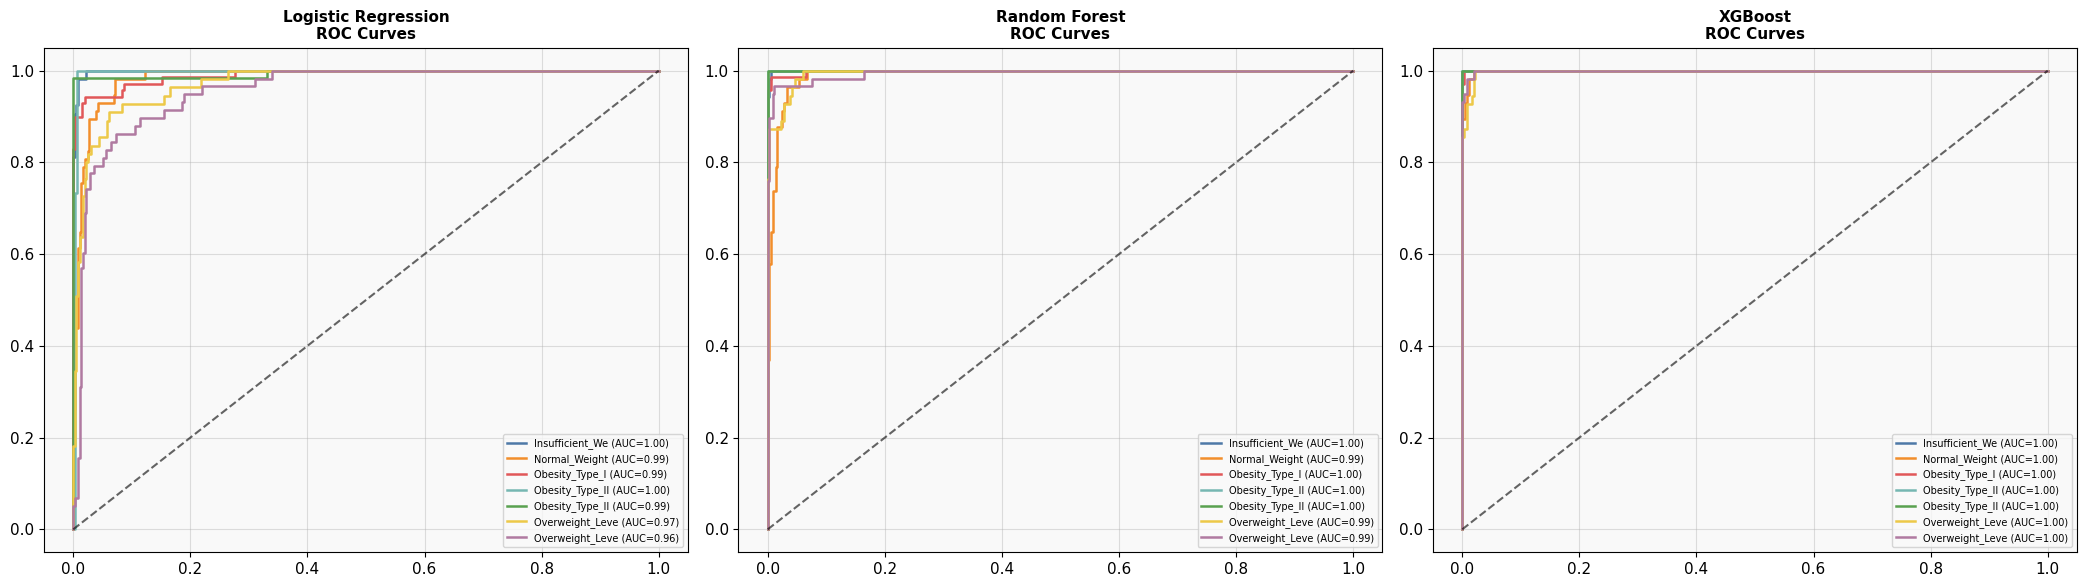

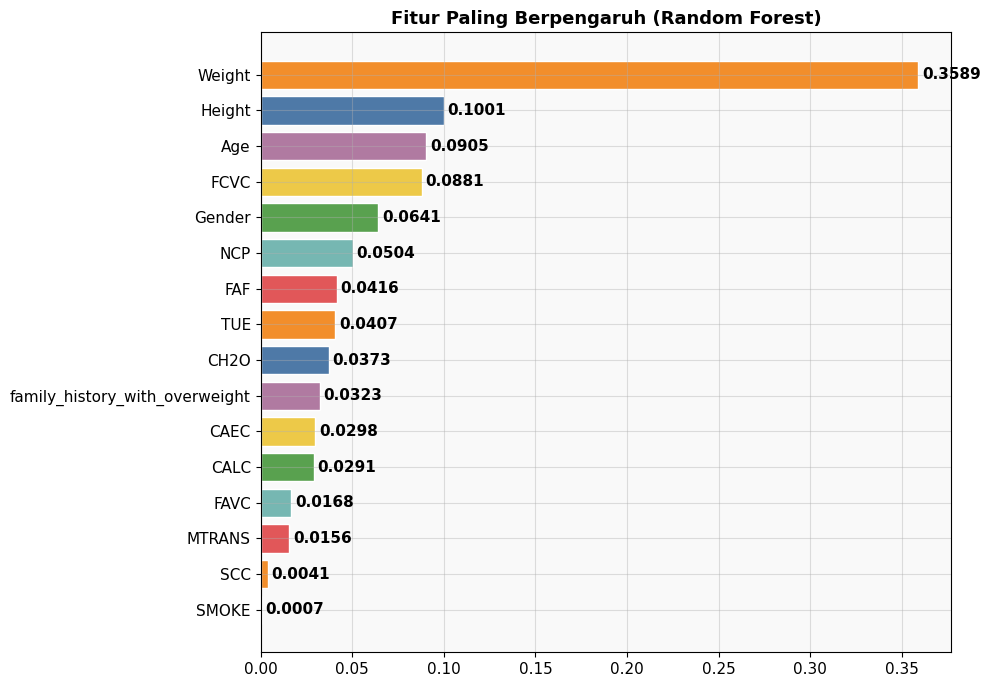

In [ ]:
# =============================================================================
# 8. EVALUASI MODEL
# =============================================================================
print("\n[8] EVALUASI MODEL")
print("-" * 45)

def evaluate_model(model, X_t, y_t, name):
    y_pred = model.predict(X_t)
    y_prob = model.predict_proba(X_t)
    try:
        auc = roc_auc_score(y_t, y_prob, multi_class='ovr', average='weighted')
    except Exception:
        auc = np.nan
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_t, y_pred), 4),
        'Precision': round(precision_score(y_t, y_pred, average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score(y_t, y_pred, average='weighted', zero_division=0), 4),
        'F1-Score' : round(f1_score(y_t, y_pred, average='weighted', zero_division=0), 4),
        'ROC-AUC'  : round(auc, 4) if not np.isnan(auc) else np.nan,
    }, y_pred, y_prob

models_dict = {
    'Logistic Regression': lr_model,
    'Random Forest'      : rf_model,
    'XGBoost'            : xgb_model,
}
results    = []
preds_dict = {}
probs_dict = {}

for name, model in models_dict.items():
    m, y_pred, y_prob = evaluate_model(model, X_test_scaled, y_test, name)
    results.append(m)
    preds_dict[name] = y_pred
    probs_dict[name] = y_prob
    print(f"\n[{name}]")
    print(f"  Accuracy  : {m['Accuracy']:.4f}")
    print(f"  F1-Score  : {m['F1-Score']:.4f}")
    print(f"\nClassification Report:\n"
          f"{classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0)}")

results_df = pd.DataFrame(results).set_index('Model')
print("\n" + "=" * 65)
print("TABEL PERBANDINGAN MODEL")
print("=" * 65)
print(results_df.to_string())

# ============================================================
# PLOT 5: Confusion Matrix (Tampilkan Langsung)
# ============================================================
fig5, axes5 = plt.subplots(1, 3, figsize=(22, 6))
for ax, (name, y_pred) in zip(axes5, preds_dict.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, ax=ax, annot=True, fmt='d', cmap='Blues',
        xticklabels=[n.replace('_', '\n') for n in CLASS_NAMES],
        yticklabels=[n.replace('_', '\n') for n in CLASS_NAMES],
        linewidths=0.5, linecolor='white',
        cbar_kws={'shrink': 0.7}
    )
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}\nAccuracy: {acc:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
plt.suptitle('Confusion Matrix — Semua Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 6: Perbandingan Metrik (Bar Chart)
# ============================================================
metrics_show = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_list   = results_df.index.tolist()
x            = np.arange(len(metrics_show))
width        = 0.25
colors_bar   = ['#4e79a7', '#f28e2b', '#e15759']

fig6, ax6 = plt.subplots(figsize=(13, 6))
for i, (name, color) in enumerate(zip(model_list, colors_bar)):
    vals = [results_df.loc[name, m] for m in metrics_show]
    rects = ax6.bar(x + i * width, vals, width, label=name, color=color, alpha=0.88, edgecolor='white')
    for rect, v in zip(rects, vals):
        ax6.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax6.set_xticks(x + width)
ax6.set_xticklabels(metrics_show)
ax6.set_ylim(0, 1.15)
ax6.set_title('Perbandingan Metrik Evaluasi Semua Model', fontsize=14, fontweight='bold')
ax6.legend(loc='upper right')
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 7: ROC-AUC Curve per Kelas
# ============================================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc as auc_score

y_test_bin = label_binarize(y_test, classes=list(range(N_CLASSES)))

fig7, axes7 = plt.subplots(1, 3, figsize=(21, 6))
for ax, (name, y_prob) in zip(axes7, probs_dict.items()):
    for k, (cls_name, color) in enumerate(zip(CLASS_NAMES, PALETTE)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, k], y_prob[:, k])
        roc_auc_k   = auc_score(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=1.8,
                label=f'{cls_name[:15]} (AUC={roc_auc_k:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.6)
    ax.set_title(f'{name}\nROC Curves', fontsize=11, fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 9: Feature Importance (Random Forest)
# ============================================================
feat_imp = pd.Series(rf_model.feature_importances_, index=FEATURE_NAMES).sort_values()
plt.figure(figsize=(10, 7))
colors_fi  = [PALETTE[i % len(PALETTE)] for i in range(len(feat_imp))]
bars9 = plt.barh(feat_imp.index, feat_imp.values, color=colors_fi, edgecolor='white')
for bar, val in zip(bars9, feat_imp.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height() / 2, f'{val:.4f}', va='center', fontweight='bold')
plt.title('Fitur Paling Berpengaruh (Random Forest)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# **Export ke ONNX**

In [ ]:
# =============================================================================
# 10. EXPORT KE ONNX
# =============================================================================
print("\n[10] EXPORT KE ONNX")
print("-" * 45)

best_model_name = results_df['F1-Score'].idxmax()
best_model_obj = models_dict[best_model_name]

onnx_pipeline = SKPipeline([
    ('scaler', scaler),
    ('model' , best_model_obj)
])

onnx_pipeline.fit(X_train, y_train)

initial_type = [('float_input', FloatTensorType([None, N_FEATURES]))]

print(f"Mengonversi '{best_model_name}' → ONNX ...")

onnx_exported = False # Initialize onnx_exported

try:

    update_registered_converter(
        xgb.XGBClassifier, 'XGBClassifier',
        xgb_model.get_booster, # Jika menggunakan XGBoost
        None
    ) if 'XGBoost' in best_model_name else None

    onnx_model = convert_sklearn(
        onnx_pipeline,
        initial_types=initial_type,
        target_opset=12,
        options={'zipmap': False} # Cara terbaru dan lebih aman
    )

    with open('model.onnx', 'wb') as f:
        f.write(onnx_model.SerializeToString())

    print(f"model.onnx disimpan ✓ ({os.path.getsize('model.onnx')/1024:.1f} KB)")
    onnx_exported = True # Set to True if export is successful

except Exception as e:
    print(f"Gagal konversi pipeline: {e}")
    # Fallback ke Random Forest (Paling stabil untuk ONNX)
    print("Mencoba fallback ke Random Forest...")
    rf_pipe = SKPipeline([('scaler', scaler), ('model', rf_model)])
    rf_pipe.fit(X_train, y_train)
    onnx_model = convert_sklearn(
        rf_pipe, initial_types=initial_type, target_opset=12,
        options={'zipmap': False}
    )
    with open('model.onnx', 'wb') as f:
        f.write(onnx_model.SerializeToString())
    print(f"model.onnx (Random Forest) berhasil diekspor sebagai cadangan ✓")
    onnx_exported = True # Set to True even for fallback if successful


[10] EXPORT KE ONNX
---------------------------------------------
Mengonversi 'XGBoost' → ONNX ...
Gagal konversi pipeline: A converter cannot be None for 'XGBClassifier'.
Mencoba fallback ke Random Forest...
model.onnx (Random Forest) berhasil diekspor sebagai cadangan ✓


# **Simulasi Inference**

In [ ]:
# =============================================================================
# 11. SIMULASI INFERENCE
# =============================================================================
print("\n[11] SIMULASI INFERENCE")
print("-" * 45)

# Ambil 1 sampel dari test set (format RAW)
# Kita gunakan .values agar menjadi numpy array murni
sample_raw = X_test.iloc[[0]].values.astype(np.float32)
true_label     = y_test.iloc[0]
true_label_str = CLASS_NAMES[int(true_label)]

print(f"Label asli: {true_label} → '{true_label_str}'")

# --- Sklearn Inference ---
# Ingat: Sklearn model (best_model_obj) berdiri sendiri tanpa scaler di dalamnya,
# jadi ia butuh data yang sudah di-scaled (X_test_scaled)
pred_sk  = best_model_obj.predict(X_test_scaled[[0]])[0]
prob_sk  = best_model_obj.predict_proba(X_test_scaled[[0]])[0]

print(f"\n[Sklearn Inference]")
print(f"  Prediksi kelas : {pred_sk} → '{CLASS_NAMES[int(pred_sk)]}'")
print(f"  Probabilitas   :")
for cls, p in zip(CLASS_NAMES, prob_sk):
    bar = '█' * int(p * 30)
    print(f"    [{p:.4f}] {bar} {cls}")

# --- ONNX Runtime Inference ---
print(f"\n[ONNX Runtime Inference]")
if onnx_exported:
    try:
        # Load session
        sess       = rt.InferenceSession('model.onnx')
        input_name = sess.get_inputs()[0].name

        # ONNX menjalankan pipeline (Scaler + Model), jadi kita masukkan sample_raw
        outputs    = sess.run(None, {input_name: sample_raw})

        # Output 0 biasanya label, Output 1 adalah probabilities (karena zipmap=False)
        pred_onnx  = outputs[0][0]
        prob_onnx  = outputs[1][0]

        print(f"  Input name     : '{input_name}'")
        print(f"  Prediksi kelas : {pred_onnx} → '{CLASS_NAMES[int(pred_onnx)]}'")
        print(f"  Probabilitas   :")
        for cls, p in zip(CLASS_NAMES, prob_onnx):
            bar = '█' * int(float(p) * 30)
            print(f"    [{float(p):.4f}] {bar} {cls}")

        # Cek Konsistensi
        konsisten = int(pred_sk) == int(pred_onnx)
        if konsisten:
            print(f"\n  HASIL: ✓ KONSISTEN (Sklearn == ONNX)")
        else:
            print(f"\n  HASIL: ✗ BERBEDA (Ada selisih pada normalisasi/model)")

    except Exception as e:
        print(f"  Error ONNX inference: {e}")


[11] SIMULASI INFERENCE
---------------------------------------------
Label asli: 6 → 'Overweight_Level_II'

[Sklearn Inference]
  Prediksi kelas : 6 → 'Overweight_Level_II'
  Probabilitas   :
    [0.0014]  Insufficient_Weight
    [0.0061]  Normal_Weight
    [0.0008]  Obesity_Type_I
    [0.0002]  Obesity_Type_II
    [0.0013]  Obesity_Type_III
    [0.0242]  Overweight_Level_I
    [0.9660] ████████████████████████████ Overweight_Level_II

[ONNX Runtime Inference]
  Input name     : 'float_input'
  Prediksi kelas : 6 → 'Overweight_Level_II'
  Probabilitas   :
    [0.0435] █ Insufficient_Weight
    [0.0867] ██ Normal_Weight
    [0.0084]  Obesity_Type_I
    [0.0062]  Obesity_Type_II
    [0.0085]  Obesity_Type_III
    [0.1126] ███ Overweight_Level_I
    [0.7341] ██████████████████████ Overweight_Level_II

  HASIL: ✓ KONSISTEN (Sklearn == ONNX)


# **Output Untuk Web**

In [ ]:
# =============================================================================
# 12. OUTPUT UNTUK WEB (Next.js + TypeScript)
# =============================================================================
print("\n[12] OUTPUT UNTUK WEB (Next.js + TypeScript)")
print("-" * 45)

# Contoh input: satu baris data nyata dari dataset (sebelum encoding)
example_raw_input = {
    "Gender"                        : "Male",    # string: Male / Female
    "Age"                           : 23.0,      # float: usia
    "Height"                        : 1.75,      # float: tinggi badan (meter)
    "Weight"                        : 77.0,      # float: berat badan (kg)
    "family_history_with_overweight": "yes",     # yes / no
    "FAVC"                          : "yes",     # yes / no (Frequent high-calorie food)
    "FCVC"                          : 2.0,       # float 1-3: frekuensi sayur
    "NCP"                           : 3.0,       # float: jumlah makan utama/hari
    "CAEC"                          : "Sometimes",# no/Sometimes/Frequently/Always
    "SMOKE"                         : "no",      # yes / no
    "CH2O"                          : 2.0,       # float 1-3: konsumsi air (liter)
    "SCC"                           : "no",      # yes / no (calorie monitoring)
    "FAF"                           : 1.0,       # float 0-3: frekuensi aktivitas fisik
    "TUE"                           : 1.0,       # float 0-2: waktu penggunaan teknologi
    "CALC"                          : "Sometimes",# no/Sometimes/Frequently/Always
    "MTRANS"                        : "Public_Transportation"  # jenis transportasi
}

# Array float32 sesuai urutan FEATURE_NAMES setelah encoding
example_encoded_array = sample_raw[0].tolist()

web_metadata = {
    "model_info": {
        "best_model"     : best_model_name,
        "n_features"     : N_FEATURES,
        "n_classes"      : N_CLASSES,
        "class_names"    : CLASS_NAMES,
        "feature_names"  : FEATURE_NAMES,
        "onnx_file"      : "model.onnx",
        "input_dtype"    : "float32",
        "input_shape"    : [1, N_FEATURES],
        "preprocessing"  : "StandardScaler terintegrasi dalam ONNX pipeline",
    },
    "encoding_guide": {
        "Gender"                        : {"Male": 1, "Female": 0},
        "family_history_with_overweight": {"yes": 1, "no": 0},
        "FAVC"                          : {"yes": 1, "no": 0},
        "SMOKE"                         : {"yes": 1, "no": 0},
        "SCC"                           : {"yes": 1, "no": 0},
        "CAEC"                          : {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3},
        "CALC"                          : {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3},
        "MTRANS"                        : dict(zip(
            le_mtrans.classes_.tolist(),
            le_mtrans.transform(le_mtrans.classes_).tolist()
        )),
    },
    "feature_order": FEATURE_NAMES,
    "example_raw_input": example_raw_input,
    "example_encoded_float32": example_encoded_array,
    "example_output": {
        "predicted_class_index": int(pred_sk),
        "predicted_class_label": CLASS_NAMES[int(pred_sk)],
        "probabilities": {
            CLASS_NAMES[i]: round(float(p), 4) for i, p in enumerate(prob_sk)
        }
    }
}

with open('web_metadata.json', 'w') as f:
    json.dump(web_metadata, f, indent=2, default=str)
print("web_metadata.json disimpan ✓")

print("""
─────────────────────────────────────────────────────────────
  PANDUAN INTEGRASI NEXT.JS + TYPESCRIPT
─────────────────────────────────────────────────────────────

1. Install dependency:
   npm install onnxruntime-web

2. Letakkan file model.onnx di folder: /public/model.onnx

3. Urutan fitur yang HARUS diikuti (16 fitur):
   Gender, Age, Height, Weight,
   family_history_with_overweight, FAVC, FCVC, NCP,
   CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS

4. Encoding sebelum dikirim ke ONNX (lihat web_metadata.json):
   - Gender       : Male=1, Female=0
   - yes/no cols  : yes=1, no=0
   - CAEC/CALC    : no=0, Sometimes=1, Frequently=2, Always=3
   - MTRANS       : lihat encoding_guide di web_metadata.json

5. Contoh kode TypeScript:
""")

ts_example = '''
// lib/obesityPredictor.ts
import * as ort from 'onnxruntime-web';

export type ObesityClass =
  | 'Insufficient_Weight'
  | 'Normal_Weight'
  | 'Obesity_Type_I'
  | 'Obesity_Type_II'
  | 'Obesity_Type_III'
  | 'Overweight_Level_I'
  | 'Overweight_Level_II';

export interface PredictionResult {
  predictedClass : ObesityClass;
  classIndex     : number;
  probabilities  : Record<ObesityClass, number>;
}

const CLASS_NAMES: ObesityClass[] = [
  'Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I',
  'Obesity_Type_II', 'Obesity_Type_III',
  'Overweight_Level_I', 'Overweight_Level_II'
];

// Encode input sesuai panduan sebelum memanggil fungsi ini
export async function predictObesity(
  encodedFeatures: number[]   // 16 nilai float32, sudah di-encode
): Promise<PredictionResult> {

  const session = await ort.InferenceSession.create('/model.onnx');

  const tensor = new ort.Tensor(
    'float32',
    new Float32Array(encodedFeatures),
    [1, 16]  // [batch_size, n_features]
  );

  const results = await session.run({ float_input: tensor });

  const classIndex = Number(results['label'].data[0]);
  const probData   = results['probabilities'].data as Float32Array;

  const probabilities = Object.fromEntries(
    CLASS_NAMES.map((name, i) => [name, parseFloat(probData[i].toFixed(4))])
  ) as Record<ObesityClass, number>;

  return {
    predictedClass : CLASS_NAMES[classIndex],
    classIndex,
    probabilities,
  };
}

// Contoh penggunaan di komponen React:
// const result = await predictObesity([1,23,1.75,77,1,1,2,3,1,0,2,0,1,1,1,4]);
// console.log(result.predictedClass);  // "Normal_Weight"
// console.log(result.probabilities);   // { Normal_Weight: 0.82, ... }
'''
print(ts_example)

print("""
6. Contoh JSON payload dari form frontend:
   {
     "Gender": "Male",
     "Age": 23,
     "Height": 1.75,
     "Weight": 77,
     "family_history_with_overweight": "yes",
     "FAVC": "yes",
     "FCVC": 2,
     "NCP": 3,
     "CAEC": "Sometimes",
     "SMOKE": "no",
     "CH2O": 2,
     "SCC": "no",
     "FAF": 1,
     "TUE": 1,
     "CALC": "Sometimes",
     "MTRANS": "Public_Transportation"
   }

7. Contoh output prediksi:
   {
     "predictedClass": "Normal_Weight",
     "classIndex": 1,
     "probabilities": {
       "Insufficient_Weight": 0.02,
       "Normal_Weight"      : 0.85,
       "Obesity_Type_I"     : 0.05,
       "Obesity_Type_II"    : 0.01,
       "Obesity_Type_III"   : 0.01,
       "Overweight_Level_I" : 0.04,
       "Overweight_Level_II": 0.02
     }
   }
─────────────────────────────────────────────────────────────
""")


[12] OUTPUT UNTUK WEB (Next.js + TypeScript)
---------------------------------------------
web_metadata.json disimpan ✓

─────────────────────────────────────────────────────────────
  PANDUAN INTEGRASI NEXT.JS + TYPESCRIPT
─────────────────────────────────────────────────────────────
 
1. Install dependency:
   npm install onnxruntime-web
 
2. Letakkan file model.onnx di folder: /public/model.onnx
 
3. Urutan fitur yang HARUS diikuti (16 fitur):
   Gender, Age, Height, Weight,
   family_history_with_overweight, FAVC, FCVC, NCP,
   CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS
 
4. Encoding sebelum dikirim ke ONNX (lihat web_metadata.json):
   - Gender       : Male=1, Female=0
   - yes/no cols  : yes=1, no=0
   - CAEC/CALC    : no=0, Sometimes=1, Frequently=2, Always=3
   - MTRANS       : lihat encoding_guide di web_metadata.json
 
5. Contoh kode TypeScript:


// lib/obesityPredictor.ts
import * as ort from 'onnxruntime-web';
 
export type ObesityClass =
  | 'Insufficient_Weight'
  |

In [ ]:
# =============================================================================
# RINGKASAN AKHIR
# =============================================================================
print("=" * 65)
print("  PIPELINE SELESAI — RINGKASAN")
print("=" * 65)
print(f"  Dataset        : {df_encoded.shape[0]} sampel, {N_FEATURES} fitur, {N_CLASSES} kelas")
print(f"  Model terbaik  : {best_model_name}")

# Extract best F1-Score and ROC-AUC from results_df for the best model
best_f1 = results_df.loc[best_model_name, 'F1-Score']
best_auc = results_df.loc[best_model_name, 'ROC-AUC']

print(f"  F1-Score       : {best_f1:.4f}")
print(f"  ROC-AUC        : {best_auc:.4f}")
print()
print("  File yang dihasilkan:")
files_out = [
    ('model.onnx'                  , 'Model produksi untuk Next.js/web'),
    ('best_model.pkl'              , 'Backup model sklearn + scaler + encoders'),
    ('web_metadata.json'           , 'Panduan encoding & integrasi frontend'),
    ('plot1_distribusi_target.png' , 'Bar chart distribusi kelas target'),
    ('plot2_histogram_numerik.png' , 'Histogram + KDE fitur numerik'),
    ('plot3_boxplot.png'           , 'Boxplot fitur vs kelas obesitas'),
    ('plot4_heatmap_korelasi.png'  , 'Heatmap korelasi seluruh fitur'),
    ('plot5_confusion_matrix.png'  , 'Confusion matrix semua model'),
    ('plot6_perbandingan_metrik.png', 'Bar chart grouped perbandingan metrik'),
    ('plot7_roc_auc_curve.png'     , 'ROC-AUC curve OvR per kelas'),
    ('plot8_linechart_metrik.png'  , 'Line chart perbandingan metrik'),
    ('plot9_feature_importance.png', 'Feature importance Random Forest'),
]
for fname, desc in files_out:
    exists = '✓' if os.path.exists(fname) else '✗'
    print(f"  [{exists}] {fname:38s} — {desc}")
print("=" * 65)

  PIPELINE SELESAI — RINGKASAN
  Dataset        : 2087 sampel, 16 fitur, 7 kelas
  Model terbaik  : XGBoost
  F1-Score       : 0.9712
  ROC-AUC        : 0.9995

  File yang dihasilkan:
  [✓] model.onnx                             — Model produksi untuk Next.js/web
  [✗] best_model.pkl                         — Backup model sklearn + scaler + encoders
  [✓] web_metadata.json                      — Panduan encoding & integrasi frontend
  [✗] plot1_distribusi_target.png            — Bar chart distribusi kelas target
  [✗] plot2_histogram_numerik.png            — Histogram + KDE fitur numerik
  [✗] plot3_boxplot.png                      — Boxplot fitur vs kelas obesitas
  [✗] plot4_heatmap_korelasi.png             — Heatmap korelasi seluruh fitur
  [✗] plot5_confusion_matrix.png             — Confusion matrix semua model
  [✗] plot6_perbandingan_metrik.png          — Bar chart grouped perbandingan metrik
  [✗] plot7_roc_auc_curve.png                — ROC-AUC curve OvR per kelas
  [✗] plot8